# Telco churn — exploration

**What this is for.** `SPEC.md` §2 sets a gate: *"I must be able to explain what each of
the top-10 features means and why it plausibly relates to churn."* S2 is about to train a
booster and fit SHAP. If that ranking is the first one I ever see, I have no independent
basis for judging whether it is real signal or a bug in the feature pipeline.

So this notebook builds **the prior that S2's SHAP output gets checked against** — plus
two numbers S2 needs anyway: `scale_pos_weight`, and the base rate that risk-band
thresholds will be argued relative to.

**What this is not.** No model is fit anywhere below. Every association here is
univariate, which means none of it accounts for features competing for the same credit —
that is exactly what SHAP will show and this will not. Nothing here is evidence about
model quality, and nothing here closes a decision gate on its own.

## 1 · Load

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score, roc_auc_score

from churn.data import TARGET, clean, load_raw

# `clean` is imported, never re-implemented: the production path and this notebook must
# agree on what the data is, or every finding below is about a different dataset.
raw = load_raw()
df = clean(raw)

NUMERIC = ["tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAL = [c for c in df.columns if c not in NUMERIC + [TARGET]]

print(f"raw     {raw.shape[0]:,} rows x {raw.shape[1]} cols")
print(f"clean   {df.shape[0]:,} rows x {df.shape[1]} cols  (customerID dropped)")
print(f"        {len(NUMERIC)} numeric, {len(CATEGORICAL)} categorical, 1 target")

df.head()

raw     7,043 rows x 21 cols
clean   7,043 rows x 20 cols  (customerID dropped)
        3 numeric, 16 categorical, 1 target


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [2]:
# One visual system for all four figures, so they read as a set.
# Palette slots 1-2 of a CVD-validated categorical ramp; grays are the chrome tokens.
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
SERIES_1, SERIES_2 = "#2a78d6", "#eb6834"  # blue = retained / magnitude, orange = churned

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 10,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.0,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.labelcolor": INK_2,
})

## 2 · Integrity

`PLAN.md` records the `TotalCharges` decision as resolved and argues it in prose. This is
the evidence behind it.

In [3]:
# Checked on the RAW frame — `clean` has already fixed this by the time df exists.
blank = pd.to_numeric(raw["TotalCharges"], errors="coerce").isna()

print(f"blank TotalCharges rows      {blank.sum()}")
print(f"  ...with tenure == 0        {(raw.loc[blank, 'tenure'] == 0).sum()}")
print(f"rows with tenure == 0        {(raw['tenure'] == 0).sum()}   <- the same 11 rows")
print(f"  their churn labels         {raw.loc[blank, TARGET].value_counts().to_dict()}")
print()
print(f"after clean(): {int(df['TotalCharges'].isna().sum())} NaN, "
      f"{int((df['TotalCharges'] == 0).sum())} zeros")

raw.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", TARGET]]

blank TotalCharges rows      11
  ...with tenure == 0        11
rows with tenure == 0        11   <- the same 11 rows
  their churn labels         {'No': 11}

after clean(): 0 NaN, 11 zeros


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [4]:
print(f"nulls anywhere after clean()          {int(df.isna().sum().sum())}")

# Duplicates are only meaningful once customerID is gone: they are customers with
# identical service profiles, not repeated records.
features = [c for c in df.columns if c != TARGET]
groups = df.groupby(features, observed=True)[TARGET].agg(n="size", churned="sum")
repeated = groups[groups["n"] > 1]
conflicting = repeated[(repeated["churned"] > 0) & (repeated["churned"] < repeated["n"])]

print(f"repeated feature profiles             {len(repeated)} groups, "
      f"{int(repeated['n'].sum())} rows")
print(f"  ...with CONFLICTING churn labels    {len(conflicting)} groups, "
      f"{int(conflicting['n'].sum())} rows "
      f"({conflicting['n'].sum() / len(df):.2%} of the dataset)")

pd.DataFrame({
    "levels": df[CATEGORICAL].nunique(),
    "values": [" | ".join(map(str, sorted(df[c].unique()))) for c in CATEGORICAL],
})

nulls anywhere after clean()          0
repeated feature profiles             33 groups, 73 rows
  ...with CONFLICTING churn labels    18 groups, 42 rows (0.60% of the dataset)


,levels,values
gender,2,Female | Male
SeniorCitizen,2,No | Yes
Partner,2,No | Yes
Dependents,2,No | Yes
PhoneService,2,No | Yes
MultipleLines,3,No | No phone service | Yes
InternetService,3,DSL | Fiber optic | No
OnlineSecurity,3,No | No internet service | Yes
OnlineBackup,3,No | No internet service | Yes
DeviceProtection,3,No | No internet service | Yes


**Finding.** The 11 blank `TotalCharges` values and the 11 `tenure == 0` rows are *the
same 11 rows*. The blank is not a missing measurement — it is a customer who has not been
billed yet, so `0.0` is the true value rather than an estimate. All 11 are `Churn == No`.
Dropping them would have deleted the only examples of the brand-new-customer state, which
is a state the live service has to score and a prime retention target.

18 groups of customers (42 rows, 0.6% of the data) have **identical feature vectors but
different outcomes**. They are kept — they are real customers, and they are the honest
signal that this feature set cannot perfectly separate churn. They put a floor under the
error rate that no model can beat. At 0.6% that floor is nowhere near binding, so it does
not constrain S2; it is just worth knowing before chasing the last point of accuracy.

## 3 · Target and imbalance

In [5]:
positives = int(df[TARGET].sum())
negatives = len(df) - positives
base_rate = positives / len(df)
scale_pos_weight = negatives / positives

print(f"churned    {positives:>6,}   {base_rate:.4f}")
print(f"retained   {negatives:>6,}   {1 - base_rate:.4f}")
print()
print(f"scale_pos_weight = negatives / positives = {scale_pos_weight:.3f}")
print(f"accuracy of a model that always says 'no churn' = {1 - base_rate:.4f}")

churned     1,869   0.2654
retained    5,174   0.7346

scale_pos_weight = negatives / positives = 2.768
accuracy of a model that always says 'no churn' = 0.7346


**Finding.** 26.54% positive. A model that predicts "nobody churns" scores **73.46%
accuracy** while being useless — which is why accuracy is not in the metrics table.

- **PR-AUC**, because precision and recall are both computed on the churners. ROC-AUC's
  denominator is dominated by the 5,174 easy negatives, so it flatters the model.
- **Brier**, because the service returns a *probability* and `/recommend` bands on it. A
  score of 0.8 has to mean 80%, not just "higher than 0.6" — ranking correctly and being
  calibrated are different properties, and only one of them survives a threshold change.

`scale_pos_weight = 2.768` is derived here rather than hardcoded in S2, so it is a number
with a reason behind it. Class weighting, not resampling — resampling would distort the
base rate the calibrator has to learn.

## 4 · Numeric features

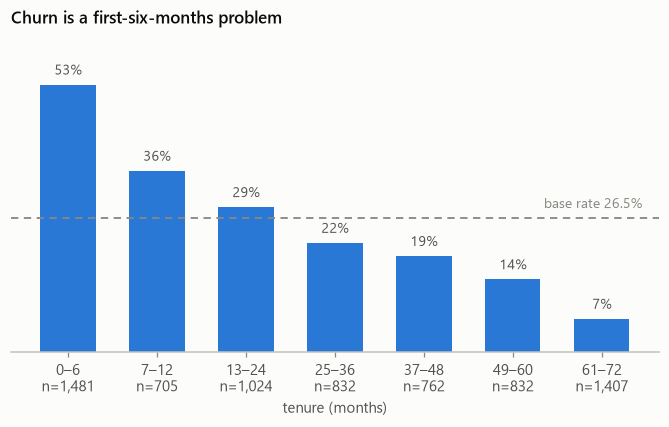

In [6]:
edges = [0, 6, 12, 24, 36, 48, 60, 72]
names = ["0–6", "7–12", "13–24", "25–36", "37–48", "49–60", "61–72"]
bucket = pd.cut(df["tenure"], bins=edges, labels=names, include_lowest=True)
by_tenure = df.groupby(bucket, observed=True)[TARGET].agg(n="size", churn_rate="mean")

fig, ax = plt.subplots(figsize=(7.6, 3.7))
x = np.arange(len(by_tenure))
ax.bar(x, by_tenure["churn_rate"], color=SERIES_1, width=0.62)
ax.axhline(base_rate, color=MUTED, linewidth=1.2, linestyle=(0, (4, 3)), zorder=3)
ax.text(x[-1] + 0.45, base_rate + 0.014, f"base rate {base_rate:.1%}",
        ha="right", va="bottom", color=MUTED, fontsize=9)

for xi, rate in zip(x, by_tenure["churn_rate"], strict=True):
    ax.text(xi, rate + 0.014, f"{rate:.0%}", ha="center", va="bottom",
            color=INK_2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\nn={c:,}" for n, c in zip(by_tenure.index, by_tenure["n"], strict=True)])
ax.set_ylim(0, 0.62)
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("tenure (months)")
ax.set_title("Churn is a first-six-months problem")
plt.show()

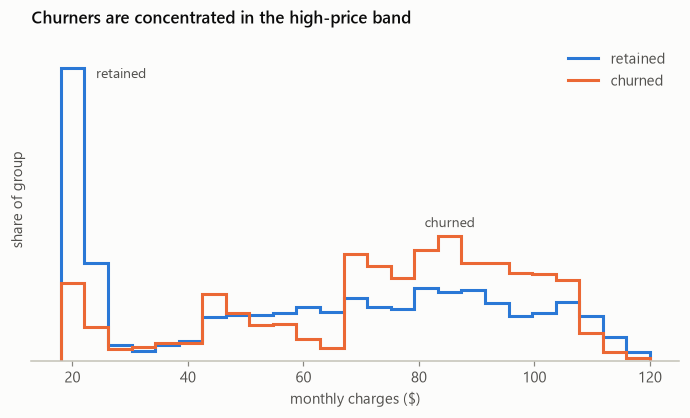

In [7]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
bins = np.linspace(18, 120, 26)
curves = {}

for label, colour, name in [(0, SERIES_1, "retained"), (1, SERIES_2, "churned")]:
    values = df.loc[df[TARGET] == label, "MonthlyCharges"]
    density, _ = np.histogram(values, bins=bins, density=True)
    ax.stairs(density, bins, color=colour, linewidth=2, label=name)
    curves[name] = density

centres = (bins[:-1] + bins[1:]) / 2

# "retained" peaks in a narrow spike, so its label goes beside the spike rather than
# on top of it, where it would run into the title.
peak = int(curves["retained"].argmax())
ax.text(bins[peak + 1] + 2.0, curves["retained"][peak], "retained",
        ha="left", va="top", color=INK_2, fontsize=9)

peak = int(curves["churned"].argmax())
ax.text(centres[peak], curves["churned"][peak] * 1.05, "churned",
        ha="center", va="bottom", color=INK_2, fontsize=9)

ax.set_ylim(0, curves["retained"].max() * 1.10)
ax.legend(loc="upper right")
ax.set_yticks([])
ax.spines["left"].set_visible(False)
ax.set_xlabel("monthly charges ($)")
ax.set_ylabel("share of group")
ax.set_title("Churners are concentrated in the high-price band")
plt.show()

In [8]:
# Single-feature ROC-AUC: what one column alone can do. Directly comparable to the
# model AUC S2 will report — that is the point of computing it.
rows = []
for column in NUMERIC:
    auc = roc_auc_score(df[TARGET], df[column])
    rows.append({
        "feature": column,
        "auc": round(auc, 4),
        "auc_oriented": round(max(auc, 1 - auc), 4),
        "direction": "higher → more churn" if auc > 0.5 else "higher → less churn",
    })

pd.DataFrame(rows).sort_values("auc_oriented", ascending=False).reset_index(drop=True)

,feature,auc,auc_oriented,direction
0,tenure,0.2601,0.7399,higher → less churn
1,TotalCharges,0.3497,0.6503,higher → less churn
2,MonthlyCharges,0.6208,0.6208,higher → more churn


**Finding.** Churn falls monotonically with tenure — **52.9%** in the first six months
against **6.6%** past five years. Tenure alone reaches ROC-AUC **0.740**.

That number is a tripwire for S2: *if the trained model's ROC-AUC is not comfortably
above 0.74, it has learned essentially nothing beyond "new customers leave."*

`MonthlyCharges` splits into two stories rather than one. The tall spike near \$20 is the
no-internet, phone-only block, and it barely churns; churners pile up above \$70. So the
apparent price effect is entangled with *product mix* — fiber costs more and churns more
— and univariate analysis cannot separate the two. SHAP, which sees them competing, can.

## 5 · Categorical features

In [9]:
frames = []
for column in CATEGORICAL:
    g = (df.groupby(column, observed=True)[TARGET]
           .agg(n="size", churn_rate="mean")
           .reset_index()
           .rename(columns={column: "level"}))
    g.insert(0, "feature", column)
    frames.append(g)

levels = pd.concat(frames, ignore_index=True)
levels["share"] = levels["n"] / len(df)
levels["lift"] = levels["churn_rate"] / base_rate
levels = levels.round({"churn_rate": 3, "share": 3, "lift": 2})

by_lift = levels.sort_values("lift", ascending=False).reset_index(drop=True)
print("HIGHEST-RISK LEVELS")
print(by_lift.head(10).to_string(index=False))
print("\nLOWEST-RISK LEVELS")
print(by_lift.tail(8).iloc[::-1].to_string(index=False))

HIGHEST-RISK LEVELS
         feature            level    n  churn_rate  share  lift
   PaymentMethod Electronic check 2365       0.453  0.336  1.71
        Contract   Month-to-month 3875       0.427  0.550  1.61
 InternetService      Fiber optic 3096       0.419  0.440  1.58
  OnlineSecurity               No 3498       0.418  0.497  1.57
   SeniorCitizen              Yes 1142       0.417  0.162  1.57
     TechSupport               No 3473       0.416  0.493  1.57
    OnlineBackup               No 3088       0.399  0.438  1.50
DeviceProtection               No 3095       0.391  0.439  1.47
 StreamingMovies               No 2785       0.337  0.395  1.27
PaperlessBilling              Yes 4171       0.336  0.592  1.26

LOWEST-RISK LEVELS
         feature               level    n  churn_rate  share  lift
        Contract            Two year 1695       0.028  0.241  0.11
 StreamingMovies No internet service 1526       0.074  0.217  0.28
     StreamingTV No internet service 1526       0.074  

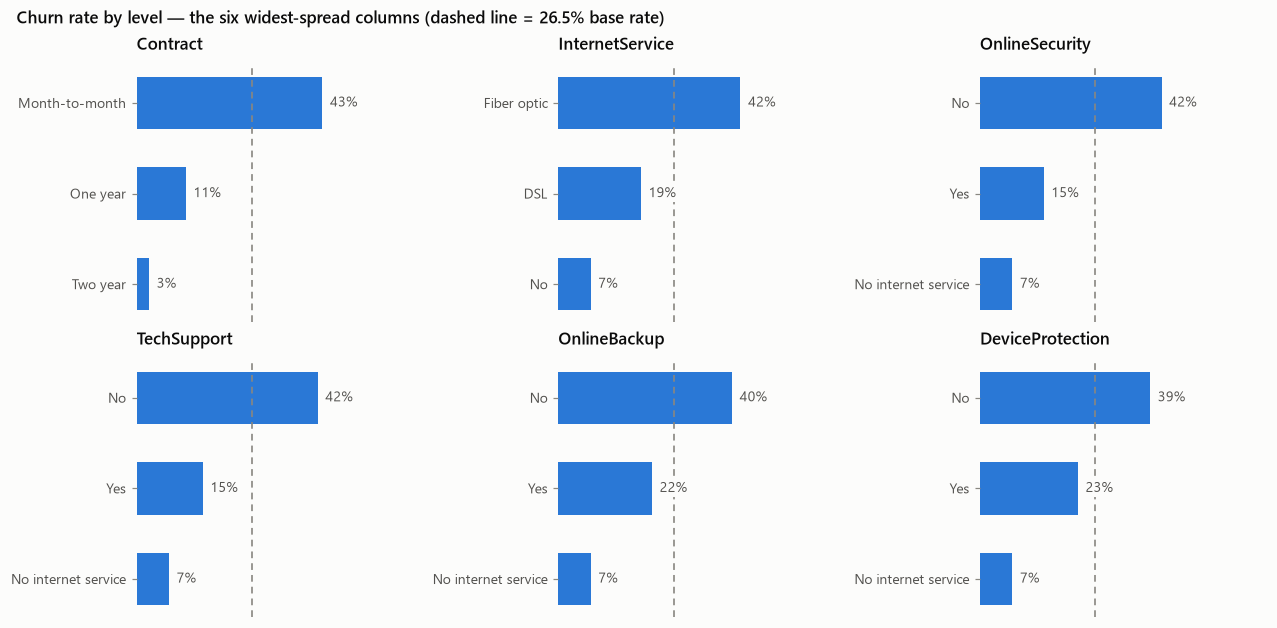

In [10]:
# Rank by churn-rate spread across levels: how much knowing this column moves the number.
spread = (levels.groupby("feature")["churn_rate"]
                .agg(lambda s: s.max() - s.min())
                .sort_values(ascending=False))
top6 = spread.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.6), layout="constrained")
for ax, column in zip(axes.ravel(), top6, strict=True):
    g = (df.groupby(column, observed=True)[TARGET]
           .agg(n="size", churn_rate="mean")
           .sort_values("churn_rate"))
    y = np.arange(len(g))
    ax.barh(y, g["churn_rate"], color=SERIES_1, height=0.58)
    ax.axvline(base_rate, color=MUTED, linewidth=1.1, linestyle=(0, (4, 3)), zorder=3)
    for yi, rate in zip(y, g["churn_rate"], strict=True):
        # Surface-coloured backing so a label landing on the base-rate line stays legible.
        ax.text(rate + 0.018, yi, f"{rate:.0%}", va="center", color=INK_2, fontsize=9,
                bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 1.5})
    ax.set_yticks(y)
    ax.set_yticklabels(g.index, fontsize=9)
    ax.set_xlim(0, 0.66)
    ax.set_xticks([])
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.set_title(column)

fig.suptitle("Churn rate by level — the six widest-spread columns "
             "(dashed line = 26.5% base rate)",
             fontsize=11, fontweight="semibold", color=INK, x=0.008, ha="left")
plt.show()

**Finding.** Six levels sit at roughly 1.6× the base rate: electronic-check payment
(45.3%), month-to-month contract (42.7%), fiber internet (41.9%), and the absence of
online security (41.8%), tech support (41.6%) or online backup (39.9%). At the other end,
a two-year contract churns at **2.8%** — a 15× swing across one column.

`gender` moves the churn rate by 0.8 percentage points and `PhoneService` by 1.8. They are
noise, and they are useful precisely because of that: if either shows up as a top SHAP
driver in S3, the feature pipeline is broken, not the customer.

One caution on reading this table: the seven "No internet service" rows all report the
identical 7.4% on the identical 1,526 customers. That is one fact printed seven times, not
seven findings — see §7.

## 6 · The ranked prior

Mutual information puts numeric and categorical features on one scale (numerics are
quantile-binned first). It measures *strength* of association only — it has no direction,
so it is read alongside the lift table above, which has direction but no common scale.

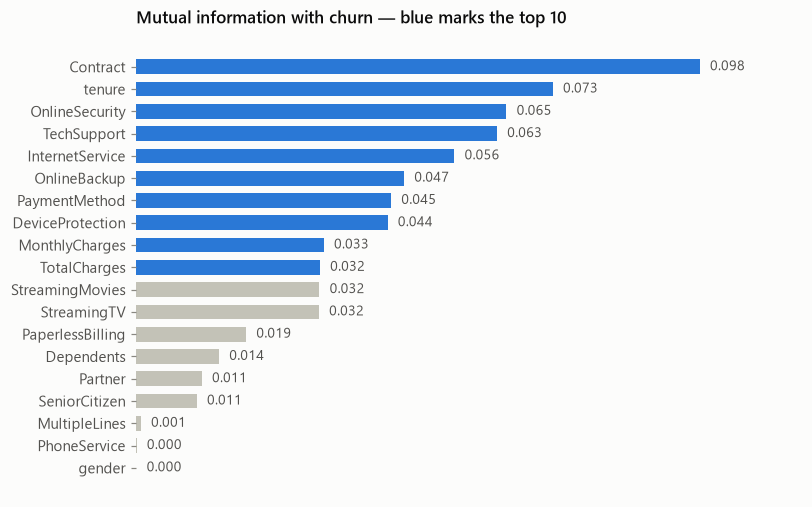

In [11]:
def mutual_information(series: pd.Series, target: pd.Series, quantiles: int = 10) -> float:
    if pd.api.types.is_numeric_dtype(series):
        series = pd.qcut(series, quantiles, duplicates="drop")
    return mutual_info_score(series.astype(str), target)


mi = (pd.Series({c: mutual_information(df[c], df[TARGET]) for c in NUMERIC + CATEGORICAL})
        .sort_values(ascending=False))
top10 = mi.head(10).index.tolist()

ordered = mi.sort_values()
colours = [SERIES_1 if name in top10 else AXIS for name in ordered.index]

fig, ax = plt.subplots(figsize=(7.8, 5.4))
y = np.arange(len(ordered))
ax.barh(y, ordered.to_numpy(), color=colours, height=0.66)
for yi, value in zip(y, ordered.to_numpy(), strict=True):
    ax.text(value + 0.0018, yi, f"{value:.3f}", va="center", color=INK_2, fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(ordered.index)
ax.set_xlim(0, mi.max() * 1.18)
ax.set_xticks([])
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.set_title("Mutual information with churn — blue marks the top 10")
plt.show()

**Finding — the prior.** `Contract` leads, then `tenure`, then the three service add-ons
(`OnlineSecurity`, `TechSupport`, `OnlineBackup`) with `InternetService` and
`PaymentMethod` interleaved. `MonthlyCharges` and `TotalCharges` place ninth and tenth
despite being the two most obvious "money" columns.

`gender` (0.00002), `PhoneService` (0.0001) and `MultipleLines` (0.0008) are three orders
of magnitude below the leaders — effectively zero.

Note that the four add-on columns are *not* four independent findings: each one carries
the same 1,526-customer no-internet block, so part of their MI is one shared fact.

## 7 · Two facts that will distort SHAP

SHAP splits credit between correlated features. Both of these are worth knowing *before*
reading a driver list, rather than discovering them while debugging one.

In [12]:
reconstructed = df["tenure"] * df["MonthlyCharges"]
billed = df["TotalCharges"] > 0
relative_error = ((df["TotalCharges"] - reconstructed).abs()[billed]
                  / df.loc[billed, "TotalCharges"])

print("correlation among the numeric columns")
print(df[NUMERIC].corr().round(3).to_string())
print()
print(f"corr(TotalCharges, tenure * MonthlyCharges)   {df['TotalCharges'].corr(reconstructed):.4f}")
print(f"median relative reconstruction error         {relative_error.median():.2%}")

correlation among the numeric columns
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000

corr(TotalCharges, tenure * MonthlyCharges)   0.9996
median relative reconstruction error         2.00%


In [13]:
shared: dict[str, list[str]] = {}
for column in CATEGORICAL:
    for level in df[column].unique():
        if str(level) in ("No internet service", "No phone service"):
            shared.setdefault(str(level), []).append(column)

for level, columns in shared.items():
    plural = "column" if len(columns) == 1 else "columns"
    print(f"{level!r} is a level in {len(columns)} {plural}:")
    for column in columns:
        print(f"    {column}")

no_internet = df["InternetService"].eq("No")
print(f"\nInternetService == 'No'   {int(no_internet.sum()):,} rows, "
      f"churn rate {df.loc[no_internet, TARGET].mean():.3f}")
print(f"one-hot width if every level is encoded: "
      f"{sum(df[c].nunique() for c in CATEGORICAL)} categorical + {len(NUMERIC)} numeric")

'No phone service' is a level in 1 column:
    MultipleLines
'No internet service' is a level in 6 columns:
    OnlineSecurity
    OnlineBackup
    DeviceProtection
    TechSupport
    StreamingTV
    StreamingMovies

InternetService == 'No'   1,526 rows, churn rate 0.074
one-hot width if every level is encoded: 43 categorical + 3 numeric


**Finding.** `TotalCharges` correlates **0.9996** with `tenure × MonthlyCharges`, with a
median reconstruction error of 2%. It is very nearly a deterministic function of the other
two columns: three numeric features, two independent quantities. SHAP will divide the
credit among all three, so a modest `TotalCharges` contribution should be read as tenure
and price wearing a third hat — not as a separate finding about lifetime spend.

`"No internet service"` is a level in **six** separate columns, and it flags the identical
1,526 customers each time, at the identical 7.4% churn rate. One-hot encoding turns 16
categorical columns into 43, of which five are exact restatements of
`InternetService == "No"`.

This is the concrete case for **open gate #3** (level-specific driver names like
`OnlineBackup=No internet service` vs. aggregating back to `OnlineBackup`). Presented, not
decided — the level-specific form is more actionable for `/recommend`, but it can put six
synonyms of one fact into a top-3 driver list. The call is the owner's, at S3.

## 8 · Findings

### The prior — top 10 by mutual information

Read against SHAP in S3. If the model's ranking looks nothing like this, the question is
which one is wrong — and having written this down first is what makes that question
answerable.

| # | Feature | MI | Why it plausibly drives churn |
|---|---|---|---|
| 1 | `Contract` | 0.099 | The only column that is literally a switching cost. Month-to-month can leave tomorrow (42.7%); a two-year customer has already pre-committed (2.8%). |
| 2 | `tenure` | 0.073 | Two effects at once — early customers have not formed a habit, and the long-tenured are survivors who already declined to leave. 52.9% → 6.6%. |
| 3 | `OnlineSecurity` | 0.065 | A bundled add-on. Each one is another thread tying the account in and another reason the bill feels like value rather than a line item. |
| 4 | `TechSupport` | 0.063 | Same add-on mechanism, plus a real one: problems that get resolved do not become cancellations. |
| 5 | `InternetService` | 0.056 | Fiber churns at 41.9%, DSL far less, no-internet at 7.4%. Fiber is the premium high-expectation product, and expectation gaps cancel. |
| 6 | `OnlineBackup` | 0.047 | Add-on, same shape as #3 and #4. |
| 7 | `PaymentMethod` | 0.045 | Electronic check is the single highest-risk level at 45.3%. Auto-pay renews passively; a manual payment is an active monthly decision to stay. |
| 8 | `DeviceProtection` | 0.044 | Add-on, same shape again. |
| 9 | `MonthlyCharges` | 0.033 | Price sensitivity — but entangled with product mix, since fiber both costs more and churns more. |
| 10 | `TotalCharges` | 0.032 | Mostly `tenure × MonthlyCharges` (r = 0.9996). Little independent content; see §7. |

**Not in the prior:** `gender`, `PhoneService`, `MultipleLines` — all effectively zero.
Any of these appearing as a top SHAP driver is a pipeline bug, not an insight.

**Four of the top eight are service add-ons** that share the same 1,526-customer
no-internet block. Expect S2's model to spread importance across them rather than
concentrating it, and do not read that spread as four independent drivers.

### Handed to S2

- `scale_pos_weight = 2.768` (5,174 / 1,869), derived rather than assumed.
- Tenure alone reaches ROC-AUC **0.740** — the floor the trained model has to clear
  before it can be said to have learned anything.
- Base rate **26.54%**; majority-class accuracy **73.46%**, which is why the metrics table
  reports PR-AUC and Brier instead.

### Gates — still open

- **#3 driver naming after one-hot.** §7 supplies the evidence: six columns restating one
  fact. Not decided here.
- **#4 risk-band thresholds.** The base rate is the reference point — a "high" band cut at
  0.60 is 2.3× base rate, and about 26.5% of customers are churners at all. The actual cut
  comes off the PR curve in S2, not from this notebook.
- **#5 confusion-matrix threshold.** Untouched. It needs a fitted model and a business
  judgement about recall on churners against the cost of a retention offer.

Nothing above is evidence about model quality. Every association here is univariate and
none of it survives contact with features competing for the same credit.